# Document CNN Model Comparison VF

Training-only notebook for document image classification. It compares one scratch CNN, the actual task-specific final VF architecture, and three pretrained baselines for each of the four document models:

- CNN1 content type
- CNN2 evidence role
- CNN3 image quality
- CNN4 authenticity/tamper screening

This notebook is for model comparison, evaluation, visual explanation, and architecture selection, not final production training.

## Coverage

- Data collection and preprocessing
- Train-only augmentation
- Image normalization and resizing
- 70 / 15 / 15 stratified split
- Scratch CNN baseline
- Task-specific final VF architecture plus three pretrained branches
- Transfer learning with frozen and fine-tune phases
- Regularization, AdamW, scheduler, cross-entropy loss
- Accuracy, macro F1, weighted F1, AUC, ECE, latency, parameters, model size
- Learning curves, confusion matrices, comparison tables
- Grad-CAM and perturbation occlusion XAI
- Final per-task winner selection

## Dependencies

In [1]:
import importlib.util, subprocess, sys, os
needed = [("cv2", "opencv-python-headless"), ("seaborn", "seaborn"), ("sklearn", "scikit-learn"), ("tqdm", "tqdm")]
missing = [pkg for mod, pkg in needed if importlib.util.find_spec(mod) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
print("Dependencies ready")

Dependencies ready


## Configuration

In [2]:
import os
from pathlib import Path

os.environ.setdefault("PIP_DISABLE_PIP_VERSION_CHECK", "1")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")
os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")
os.environ.setdefault("TORCH_HOME", "/kaggle/working/torch_cache")

B = "/kaggle/input/datasets"
CFG = {
    "output_dir": "/kaggle/working/document_model_comparison_light",
    "img_size": 160,
    "batch_size": 48,
    "num_workers": 2,
    "seed": 42,
    "max_per_class_content": 120,
    "max_per_class_evidence": 160,
    "max_per_class_quality": 180,
    "max_per_class_tamper": 180,
    "scratch_epochs": 4,
    "pretrain_frozen_epochs": 1,
    "pretrain_full_epochs": 2,
    "final_vf_full_epochs": 3,
    "lr_scratch": 8e-4,
    "lr_head": 9e-4,
    "lr_backbone": 8e-5,
    "weight_decay": 1e-4,
    "label_smoothing": 0.04,
    "dropout": 0.25,
    "mixup_alpha": 0.12,
    "xai_examples_per_task": 2,
    "latency_reps": 16,
    "ds_rvlcdip": f"{B}/pdavpoojan/the-rvlcdip-dataset-test/test",
    "ds_tobacco": f"{B}/patrickaudriaz/tobacco3482jpg/Tobacco3482-jpg",
    "ds_isic_imgs": f"{B}/nischaydnk/isic-2019-jpg-224x224-resized/train-image/image",
    "ds_mura": f"{B}/cjinny/mura-v11/MURA-v1.1",
    "ds_nih": f"{B}/organizations/nih-chest-xrays/data",
    "ds_disaster": f"{B}/varpit94/disaster-images-dataset/Comprehensive Disaster Dataset(CDD)",
    "ds_damaged": f"{B}/mehrael/damaged-buildings-dataset/DamadgedBuildingsDataset",
    "ds_hurricane": f"{B}/kmader/satellite-images-of-hurricane-damage",
    "ds_screenshots": f"{B}/patzold/screenshots-dataset",
    "ds_android": f"{B}/uzairkhan45/categorized-android-apps-screenshots/Categorized_Andriod_Apps_Images",
    "ds_cedar": f"{B}/shreelakshmigp/cedardataset/signatures",
    "ds_sigver": f"{B}/akashgundu/signature-verification-dataset/extract",
    "ds_signet": f"{B}/victordibia/signverod",
    "ds_ahcd_imgs": f"{B}/skanderkammoun/ahcd-arabic-handwriting/Arabic Handwritten Characters Dataset CSV/training images/training images.csv",
    "ds_indoor": f"{B}/itsahmad/indoor-scenes-cvpr-2019/indoorCVPR_09/Images",
    "ds_kadid_imgs": f"{B}/srachejack/kadid10k/images",
    "ds_kadid_csv": f"{B}/srachejack/kadid10k/image_labeled_by_per_noise.csv",
    "ds_biq_dir": f"{B}/nisarahmedrana/biq2021",
    "ds_biq_csv": f"{B}/nisarahmedrana/biq2021/BIQ2021.csv",
    "ds_casia": f"{B}/divg07/casia-20-image-tampering-detection-dataset/CASIA2",
    "ds_realfake": f"{B}/shivamardeshna/real-and-fake-images-dataset-for-image-forensics/Data Set 1/Data Set 1",
    "ds_cg1050_tr": f"{B}/saurabhshahane/cg1050/TRAINING_CG-1050/TRAINING",
    "ds_cg1050_val": f"{B}/saurabhshahane/cg1050/VALIDATION_CG-1050/VALIDATION",
}
Path(CFG["output_dir"]).mkdir(parents=True, exist_ok=True)
print("Config loaded")

Config loaded


## Imports and Reproducibility

In [3]:
import gc, json, random, time, warnings
from pathlib import Path
from collections import Counter

import cv2
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_auc_score, precision_recall_fscore_support
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")
random.seed(CFG["seed"])
np.random.seed(CFG["seed"])
torch.manual_seed(CFG["seed"])
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(CFG["seed"])
    torch.backends.cudnn.benchmark = True
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


## Labels and Tasks

In [4]:
CONTENT_LABELS = ["injury_photo", "scene_damage", "screenshot", "typed_document", "correspondence", "handwritten", "medical_record", "data_chart", "signature_stamp", "irrelevant"]
EVIDENCE_LABELS = ["primary_evidence", "secondary_evidence"]
QUALITY_LABELS = ["clear", "acceptable", "degraded"]
TAMPER_LABELS = ["authentic", "tampered"]

TASKS = {
    "cnn1_content": {"labels": CONTENT_LABELS, "max_per_class": CFG["max_per_class_content"], "final_arch": "final_effnetv2s_gem", "arches": ["scratch_cnn", "final_effnetv2s_gem", "mobilenet_v3_small", "efficientnet_b0", "resnet18"]},
    "cnn2_evidence": {"labels": EVIDENCE_LABELS, "max_per_class": CFG["max_per_class_evidence"], "final_arch": "final_resnext50", "arches": ["scratch_cnn", "final_resnext50", "mobilenet_v3_small", "efficientnet_b0", "resnet18"]},
    "cnn3_quality": {"labels": QUALITY_LABELS, "max_per_class": CFG["max_per_class_quality"], "final_arch": "final_effnetb0", "arches": ["scratch_cnn", "final_effnetb0", "mobilenet_v3_small", "resnet18", "shufflenet_v2_x1_0"]},
    "cnn4_tamper": {"labels": TAMPER_LABELS, "max_per_class": CFG["max_per_class_tamper"], "final_arch": "final_effnetb1", "arches": ["scratch_cnn", "final_effnetb1", "mobilenet_v3_small", "efficientnet_b0", "resnet18"]},
}
ARCH_DISPLAY = {
    "scratch_cnn": "Scratch CNN",
    "final_effnetv2s_gem": "VF EfficientNetV2-S + GeM",
    "final_resnext50": "VF ResNeXt-50",
    "final_effnetb0": "VF EfficientNet-B0",
    "final_effnetb1": "VF EfficientNet-B1",
    "mobilenet_v3_small": "MobileNetV3-Small",
    "efficientnet_b0": "EfficientNet-B0",
    "resnet18": "ResNet-18",
    "shufflenet_v2_x1_0": "ShuffleNetV2 x1.0",
}
print("Tasks ready")

Tasks ready


## Dataset Scanners

In [5]:
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

def find_imgs(root, limit=None):
    root = Path(root)
    if not root.exists():
        return []
    out = []
    for p in root.rglob("*"):
        if p.is_file() and p.suffix.lower() in IMG_EXTS:
            out.append(p)
            if limit and len(out) >= limit:
                break
    return out

def cap_by_label(samples, labels, max_per_class):
    buckets = {label: [] for label in labels}
    random.shuffle(samples)
    seen = set()
    for path, label, source in samples:
        if label not in buckets or len(buckets[label]) >= max_per_class:
            continue
        key = str(path)
        if key in seen:
            continue
        seen.add(key)
        buckets[label].append((str(path), label, source))
    return [item for label in labels for item in buckets[label]]

def audit_samples(name, samples, labels):
    counts = Counter(label for _, label, _ in samples)
    print(f"{name}: {len(samples)} | {dict(counts)}")
    missing = [label for label in labels if counts.get(label, 0) < 8]
    if missing:
        print(f"Missing or tiny classes: {missing}")
    return {"task": name, "total": len(samples), "counts": dict(counts), "missing_or_tiny": missing}

RVL_MAP = {"advertisement": "irrelevant", "budget": "data_chart", "email": "correspondence", "file_folder": "irrelevant", "form": "typed_document", "handwritten": "handwritten", "invoice": "typed_document", "letter": "correspondence", "memo": "correspondence", "news_article": "typed_document", "presentation": "data_chart", "questionnaire": "typed_document", "resume": "typed_document", "scientific_publication": "typed_document", "scientific_report": "typed_document", "specification": "typed_document"}
TOBACCO_MAP = {"ADVE": "irrelevant", "Email": "correspondence", "Form": "typed_document", "Letter": "correspondence", "Memo": "correspondence", "News": "typed_document", "Note": "handwritten", "Report": "typed_document", "Resume": "typed_document", "Scientific": "typed_document"}
DISASTER_DMG = {"Damaged_Infrastructure", "Fire_Disaster", "Human_Damage", "Land_Disaster", "Water_Disaster"}

def scan_rvlcdip():
    root = Path(CFG["ds_rvlcdip"])
    out = []
    if root.exists():
        for d in sorted(root.iterdir()):
            if d.is_dir() and d.name in RVL_MAP:
                out.extend((str(f), RVL_MAP[d.name], "rvlcdip") for f in find_imgs(d, 900))
    return out

def scan_tobacco():
    root = Path(CFG["ds_tobacco"])
    out = []
    if root.exists():
        for d in sorted(root.iterdir()):
            if d.is_dir() and d.name in TOBACCO_MAP:
                out.extend((str(f), TOBACCO_MAP[d.name], "tobacco") for f in find_imgs(d, 500))
    return out

def scan_isic():
    return [(str(f), "injury_photo", "isic") for f in find_imgs(CFG["ds_isic_imgs"], 900)]

def scan_mura():
    root = Path(CFG["ds_mura"])
    return [(str(f), "medical_record", "mura") for sub in ["train", "valid"] for f in find_imgs(root / sub, 900)]

def scan_nih():
    out = []
    root = Path(CFG["ds_nih"])
    if root.exists():
        for d in sorted(root.glob("images_*/images")):
            out.extend((str(f), "medical_record", "nih") for f in find_imgs(d, 500))
            if len(out) >= 900:
                break
    return out

def scan_disaster():
    root = Path(CFG["ds_disaster"])
    out = []
    if root.exists():
        for d in sorted(root.iterdir()):
            if d.is_dir() and d.name in DISASTER_DMG:
                out.extend((str(f), "scene_damage", "disaster") for f in find_imgs(d, 500))
            elif d.is_dir() and d.name == "Non_Damage":
                out.extend((str(f), "irrelevant", "disaster") for f in find_imgs(d, 500))
    return out

def scan_damaged():
    root = Path(CFG["ds_damaged"])
    return [(str(f), "scene_damage", "damaged") for sub in ["db", "db2", "Aug_db"] for f in find_imgs(root / sub, 500)]

def scan_hurricane():
    root = Path(CFG["ds_hurricane"])
    out = []
    if root.exists():
        for d in sorted(root.iterdir()):
            if d.is_dir():
                out.extend((str(f), "scene_damage", "hurricane") for f in find_imgs(d / "damage", 500))
                out.extend((str(f), "irrelevant", "hurricane") for f in find_imgs(d / "no_damage", 500))
    return out

def scan_screenshots():
    return [(str(f), "screenshot", "screenshots") for f in find_imgs(CFG["ds_screenshots"], 800)]

def scan_android():
    return [(str(f), "screenshot", "android") for f in find_imgs(CFG["ds_android"], 800)]

def scan_cedar():
    root = Path(CFG["ds_cedar"])
    return [(str(f), "signature_stamp", "cedar") for sub in ["full_org", "full_forg"] for f in find_imgs(root / sub, 500)]

def scan_sigver():
    return [(str(f), "signature_stamp", "sigver") for f in find_imgs(CFG["ds_sigver"], 800)]

def scan_signet():
    return [(str(f), "signature_stamp", "signet") for f in find_imgs(CFG["ds_signet"], 800)]

def scan_ahcd():
    cache = Path("/kaggle/working/ahcd_light")
    existing = sorted(cache.glob("*.png")) if cache.exists() else []
    if len(existing) >= 100:
        return [(str(f), "handwritten", "ahcd") for f in existing[:800]]
    csv_path = Path(CFG["ds_ahcd_imgs"])
    if not csv_path.exists():
        return []
    df = pd.read_csv(csv_path, header=None, nrows=900)
    cache.mkdir(parents=True, exist_ok=True)
    out = []
    for i in range(min(len(df), 800)):
        px = df.iloc[i].values.astype(np.uint8)
        if len(px) >= 4096:
            img = Image.fromarray(px[:4096].reshape(64, 64), mode="L").convert("RGB")
            fp = cache / f"ahcd_{i}.png"
            img.save(fp)
            out.append((str(fp), "handwritten", "ahcd"))
    return out

def scan_indoor():
    return [(str(f), "irrelevant", "indoor") for f in find_imgs(CFG["ds_indoor"], 800)]

def scan_kadid():
    csv_path = Path(CFG["ds_kadid_csv"])
    img_dir = Path(CFG["ds_kadid_imgs"])
    out = []
    if csv_path.exists():
        df = pd.read_csv(csv_path)
        for _, row in df.iterrows():
            fp = img_dir / str(row["image"])
            if fp.exists():
                d = float(row["dmos"])
                label = "clear" if d >= 4.0 else "acceptable" if d >= 2.5 else "degraded"
                out.append((str(fp), label, "kadid"))
    return out

def scan_biq2021():
    csv_path = Path(CFG["ds_biq_csv"])
    img_dir = Path(CFG["ds_biq_dir"])
    out = []
    if csv_path.exists():
        df = pd.read_csv(csv_path)
        for _, row in df.iterrows():
            fp = img_dir / str(row["Images"])
            if fp.exists():
                m = float(row["MOS"])
                label = "clear" if m >= 0.65 else "acceptable" if m >= 0.40 else "degraded"
                out.append((str(fp), label, "biq2021"))
    return out

def scan_casia():
    root = Path(CFG["ds_casia"])
    return [(str(f), "authentic", "casia") for f in find_imgs(root / "Au", 900)] + [(str(f), "tampered", "casia") for f in find_imgs(root / "Tp", 900)]

def scan_realfake():
    root = Path(CFG["ds_realfake"])
    out = []
    for split in ["train", "test", "validation"]:
        out.extend((str(f), "tampered", "realfake") for f in find_imgs(root / split / "fake", 500))
        out.extend((str(f), "authentic", "realfake") for f in find_imgs(root / split / "real", 500))
    return out

def scan_cg1050():
    out = []
    for base in [Path(CFG["ds_cg1050_tr"]), Path(CFG["ds_cg1050_val"])]:
        out.extend((str(f), "authentic", "cg1050") for f in find_imgs(base / "ORIGINAL", 500))
        out.extend((str(f), "tampered", "cg1050") for f in find_imgs(base / "TAMPERED", 500))
    return out

print("Scanners ready")

Scanners ready


## Data Collection and 70 / 15 / 15 Split

In [6]:
def build_content_samples():
    scanners = [scan_rvlcdip, scan_tobacco, scan_isic, scan_mura, scan_nih, scan_disaster, scan_damaged, scan_hurricane, scan_screenshots, scan_android, scan_cedar, scan_sigver, scan_signet, scan_ahcd, scan_indoor]
    samples = []
    for fn in scanners:
        samples.extend(fn())
    return cap_by_label(samples, CONTENT_LABELS, CFG["max_per_class_content"])

def build_evidence_samples(content_samples=None):
    content_samples = content_samples or build_content_samples()
    primary = {"injury_photo", "scene_damage", "medical_record", "signature_stamp", "screenshot"}
    return cap_by_label([(path, "primary_evidence" if label in primary else "secondary_evidence", source) for path, label, source in content_samples], EVIDENCE_LABELS, CFG["max_per_class_evidence"])

def build_quality_samples():
    return cap_by_label(scan_kadid() + scan_biq2021(), QUALITY_LABELS, CFG["max_per_class_quality"])

def build_tamper_samples():
    return cap_by_label(scan_casia() + scan_realfake() + scan_cg1050(), TAMPER_LABELS, CFG["max_per_class_tamper"])

def stratified_split(samples, labels):
    c2i = {c: i for i, c in enumerate(labels)}
    df = pd.DataFrame(samples, columns=["path", "label", "source"])
    df = df[df["label"].isin(labels)].drop_duplicates("path").reset_index(drop=True)
    y = df["label"].map(c2i).values
    train_df, temp_df = train_test_split(df, test_size=0.30, random_state=CFG["seed"], stratify=y)
    y_temp = temp_df["label"].map(c2i).values
    val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=CFG["seed"], stratify=y_temp)
    return train_df.reset_index(drop=True), val_df.reset_index(drop=True), test_df.reset_index(drop=True), c2i

CONTENT_SAMPLES = build_content_samples()
DATASETS = {
    "cnn1_content": CONTENT_SAMPLES,
    "cnn2_evidence": build_evidence_samples(CONTENT_SAMPLES),
    "cnn3_quality": build_quality_samples(),
    "cnn4_tamper": build_tamper_samples(),
}
DATA_AUDIT = []
SPLITS = {}
for task, samples in DATASETS.items():
    labels = TASKS[task]["labels"]
    DATA_AUDIT.append(audit_samples(task, samples, labels))
    counts = Counter(label for _, label, _ in samples)
    SPLITS[task] = stratified_split(samples, labels) if len(samples) and all(counts.get(label, 0) >= 8 for label in labels) else None
pd.DataFrame(DATA_AUDIT)

cnn1_content: 1200 | {'injury_photo': 120, 'scene_damage': 120, 'screenshot': 120, 'typed_document': 120, 'correspondence': 120, 'handwritten': 120, 'medical_record': 120, 'data_chart': 120, 'signature_stamp': 120, 'irrelevant': 120}
cnn2_evidence: 320 | {'primary_evidence': 160, 'secondary_evidence': 160}
cnn3_quality: 540 | {'clear': 180, 'acceptable': 180, 'degraded': 180}
cnn4_tamper: 360 | {'authentic': 180, 'tampered': 180}


,task,total,counts,missing_or_tiny
0,cnn1_content,1200,"{'injury_photo': 120, 'scene_damage': 120, 'sc...",[]
1,cnn2_evidence,320,"{'primary_evidence': 160, 'secondary_evidence'...",[]
2,cnn3_quality,540,"{'clear': 180, 'acceptable': 180, 'degraded': ...",[]
3,cnn4_tamper,360,"{'authentic': 180, 'tampered': 180}",[]


## Preprocessing and Loaders

In [7]:
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((CFG["img_size"], CFG["img_size"])),
    transforms.RandomHorizontalFlip(p=0.35),
    transforms.RandomRotation(6),
    transforms.ColorJitter(brightness=0.12, contrast=0.16, saturation=0.08),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
eval_tf = transforms.Compose([transforms.Resize((CFG["img_size"], CFG["img_size"])), transforms.ToTensor(), transforms.Normalize(MEAN, STD)])

class ImgDS(Dataset):
    def __init__(self, frame, c2i, tf):
        self.frame = frame.reset_index(drop=True)
        self.c2i = c2i
        self.tf = tf
    def __len__(self):
        return len(self.frame)
    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        try:
            img = Image.open(row.path).convert("RGB")
        except Exception:
            img = Image.new("RGB", (CFG["img_size"], CFG["img_size"]), "white")
        return self.tf(img), self.c2i[row.label]

def loaders_for(task):
    split = SPLITS[task]
    if split is None:
        return None
    train_df, val_df, test_df, c2i = split
    return (
        DataLoader(ImgDS(train_df, c2i, train_tf), batch_size=CFG["batch_size"], shuffle=True, num_workers=CFG["num_workers"], pin_memory=True),
        DataLoader(ImgDS(val_df, c2i, eval_tf), batch_size=CFG["batch_size"], shuffle=False, num_workers=CFG["num_workers"], pin_memory=True),
        DataLoader(ImgDS(test_df, c2i, eval_tf), batch_size=CFG["batch_size"], shuffle=False, num_workers=CFG["num_workers"], pin_memory=True),
        c2i,
    )

print("Loaders ready")

Loaders ready


## Modelling Objective

Each task is a supervised image-classification problem. The notebook compares a scratch CNN baseline, the real final VF architecture for that task, and three pretrained baselines using the same split and evaluation protocol.

In [8]:
class GeM(nn.Module):
    def __init__(self, p=3.0, eps=1e-6):
        super().__init__()
        self.p = nn.Parameter(torch.ones(1) * p)
        self.eps = eps
    def forward(self, x):
        return F.avg_pool2d(x.clamp(min=self.eps).pow(self.p), (x.size(-2), x.size(-1))).pow(1.0 / self.p)

class ScratchDocCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 24, 3, padding=1), nn.BatchNorm2d(24), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(24, 48, 3, padding=1), nn.BatchNorm2d(48), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(48, 96, 3, padding=1), nn.BatchNorm2d(96), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(96, 160, 3, padding=1), nn.BatchNorm2d(160), nn.ReLU(inplace=True), nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Sequential(nn.Flatten(), nn.Dropout(CFG["dropout"]), nn.Linear(160, num_classes))
    def forward(self, x):
        return self.classifier(self.features(x))

class EfficientNetGemHead(nn.Module):
    def __init__(self, variant, num_classes, pretrained=True):
        super().__init__()
        weights = None
        if pretrained and variant == "v2s":
            weights = models.EfficientNet_V2_S_Weights.DEFAULT
        elif pretrained and variant == "b0":
            weights = models.EfficientNet_B0_Weights.DEFAULT
        elif pretrained and variant == "b1":
            weights = models.EfficientNet_B1_Weights.DEFAULT
        if variant == "v2s":
            base = models.efficientnet_v2_s(weights=weights)
        elif variant == "b0":
            base = models.efficientnet_b0(weights=weights)
        elif variant == "b1":
            base = models.efficientnet_b1(weights=weights)
        else:
            raise ValueError(variant)
        in_features = base.classifier[-1].in_features
        self.features = base.features
        self.pool = GeM()
        self.classifier = nn.Sequential(nn.Flatten(), nn.Dropout(CFG["dropout"]), nn.Linear(in_features, num_classes))
        self.head_params = list(self.pool.parameters()) + list(self.classifier.parameters())
    def forward(self, x):
        return self.classifier(self.pool(self.features(x)))

class TorchvisionHead(nn.Module):
    def __init__(self, name, num_classes, pretrained=True):
        super().__init__()
        self.name = name
        weights = None
        try:
            if pretrained and name == "mobilenet_v3_small":
                weights = models.MobileNet_V3_Small_Weights.DEFAULT
            if pretrained and name == "efficientnet_b0":
                weights = models.EfficientNet_B0_Weights.DEFAULT
            if pretrained and name == "resnet18":
                weights = models.ResNet18_Weights.DEFAULT
            if pretrained and name == "resnext50_32x4d":
                weights = models.ResNeXt50_32X4D_Weights.DEFAULT
            if pretrained and name == "shufflenet_v2_x1_0":
                weights = models.ShuffleNet_V2_X1_0_Weights.DEFAULT
        except Exception:
            weights = None
        if name == "mobilenet_v3_small":
            self.model = models.mobilenet_v3_small(weights=weights)
            self.model.classifier[-1] = nn.Linear(self.model.classifier[-1].in_features, num_classes)
            self.head_params = list(self.model.classifier.parameters())
        elif name == "efficientnet_b0":
            self.model = models.efficientnet_b0(weights=weights)
            self.model.classifier[-1] = nn.Linear(self.model.classifier[-1].in_features, num_classes)
            self.head_params = list(self.model.classifier.parameters())
        elif name == "resnet18":
            self.model = models.resnet18(weights=weights)
            self.model.fc = nn.Sequential(nn.Dropout(CFG["dropout"]), nn.Linear(self.model.fc.in_features, num_classes))
            self.head_params = list(self.model.fc.parameters())
        elif name == "resnext50_32x4d":
            self.model = models.resnext50_32x4d(weights=weights)
            self.model.fc = nn.Sequential(nn.Dropout(CFG["dropout"]), nn.Linear(self.model.fc.in_features, num_classes))
            self.head_params = list(self.model.fc.parameters())
        elif name == "shufflenet_v2_x1_0":
            self.model = models.shufflenet_v2_x1_0(weights=weights)
            self.model.fc = nn.Sequential(nn.Dropout(CFG["dropout"]), nn.Linear(self.model.fc.in_features, num_classes))
            self.head_params = list(self.model.fc.parameters())
        else:
            raise ValueError(name)
    def forward(self, x):
        return self.model(x)

def build_model(arch, num_classes):
    if arch == "scratch_cnn":
        return ScratchDocCNN(num_classes)
    try:
        if arch == "final_effnetv2s_gem":
            return EfficientNetGemHead("v2s", num_classes, pretrained=True)
        if arch == "final_effnetb0":
            return EfficientNetGemHead("b0", num_classes, pretrained=True)
        if arch == "final_effnetb1":
            return EfficientNetGemHead("b1", num_classes, pretrained=True)
        if arch == "final_resnext50":
            return TorchvisionHead("resnext50_32x4d", num_classes, pretrained=True)
        return TorchvisionHead(arch, num_classes, pretrained=True)
    except Exception as e:
        print(f"{arch} pretrained load failed, using same architecture without weights: {e}")
        if arch == "final_effnetv2s_gem":
            return EfficientNetGemHead("v2s", num_classes, pretrained=False)
        if arch == "final_effnetb0":
            return EfficientNetGemHead("b0", num_classes, pretrained=False)
        if arch == "final_effnetb1":
            return EfficientNetGemHead("b1", num_classes, pretrained=False)
        if arch == "final_resnext50":
            return TorchvisionHead("resnext50_32x4d", num_classes, pretrained=False)
        return TorchvisionHead(arch, num_classes, pretrained=False)

print("Models ready")

Models ready


## Training and Evaluation Utilities

In [9]:
def count_params(model):
    return int(sum(p.numel() for p in model.parameters()))

def freeze_backbone(model, frozen=True):
    if hasattr(model, "head_params"):
        for p in model.parameters():
            p.requires_grad = not frozen
        for p in model.head_params:
            p.requires_grad = True

def mixup(x, y, alpha):
    if alpha <= 0 or x.size(0) < 2:
        return x, y, y, 1.0
    lam = np.random.beta(alpha, alpha)
    lam = max(lam, 1 - lam)
    idx = torch.randperm(x.size(0), device=x.device)
    return lam * x + (1 - lam) * x[idx], y, y[idx], lam

def loss_mix(criterion, pred, ya, yb, lam):
    return lam * criterion(pred, ya) + (1 - lam) * criterion(pred, yb)

@torch.no_grad()
def collect_outputs(model, loader):
    model.eval()
    logits, labels = [], []
    for x, y in loader:
        x = x.to(DEVICE, non_blocking=True)
        logits.append(model(x).detach().cpu())
        labels.append(y.cpu())
    logits = torch.cat(logits).float()
    labels = torch.cat(labels).long()
    probs = torch.softmax(logits, dim=1).numpy()
    preds = probs.argmax(1)
    return {"logits": logits.numpy(), "probs": probs, "preds": preds, "labels": labels.numpy()}

def ece_score(probs, labels, bins=15):
    conf = probs.max(axis=1)
    pred = probs.argmax(axis=1)
    acc = (pred == labels).astype(float)
    ece = 0.0
    edges = np.linspace(0, 1, bins + 1)
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (conf > lo) & (conf <= hi)
        if m.any():
            ece += abs(acc[m].mean() - conf[m].mean()) * m.mean()
    return float(ece)

def safe_auc(labels, probs, n_classes):
    try:
        if n_classes == 2:
            return float(roc_auc_score(labels, probs[:, 1]))
        return float(roc_auc_score(labels, probs, multi_class="ovr", average="macro"))
    except Exception:
        return None

def metrics_from_output(output, class_names):
    y = output["labels"]
    p = output["preds"]
    probs = output["probs"]
    n = len(class_names)
    pr, rc, f1, sup = precision_recall_fscore_support(y, p, labels=list(range(n)), zero_division=0)
    return {
        "accuracy": float(accuracy_score(y, p)),
        "macro_f1": float(f1_score(y, p, average="macro", zero_division=0)),
        "weighted_f1": float(f1_score(y, p, average="weighted", zero_division=0)),
        "auc_macro_ovr": safe_auc(y, probs, n),
        "ece": ece_score(probs, y),
        "per_class": {class_names[i]: {"precision": float(pr[i]), "recall": float(rc[i]), "f1": float(f1[i]), "support": int(sup[i])} for i in range(n)},
    }

def train_one_epoch(model, loader, optimizer, criterion, scheduler=None):
    model.train()
    total_loss, total_ok, total = 0.0, 0, 0
    for x, y in loader:
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)
        mx, ya, yb, lam = mixup(x, y, CFG["mixup_alpha"])
        out = model(mx)
        loss = loss_mix(criterion, out, ya, yb, lam)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        if scheduler:
            scheduler.step()
        total_loss += float(loss.item()) * y.size(0)
        total_ok += int(out.argmax(1).eq(y).sum().item())
        total += int(y.size(0))
    return total_loss / max(total, 1), total_ok / max(total, 1)

def validate(model, loader, class_names):
    out = collect_outputs(model, loader)
    return metrics_from_output(out, class_names), out

def fit_model(task, arch, loaders, class_names):
    train_dl, val_dl, test_dl, c2i = loaders
    model = build_model(arch, len(class_names)).to(DEVICE)
    criterion = nn.CrossEntropyLoss(label_smoothing=CFG["label_smoothing"])
    history = []
    best_state, best_f1 = None, -1.0
    if arch == "scratch_cnn":
        phases = [("scratch", CFG["scratch_epochs"], CFG["lr_scratch"])]
    elif arch == TASKS[task]["final_arch"]:
        phases = [("frozen", CFG["pretrain_frozen_epochs"], CFG["lr_head"]), ("full", CFG["final_vf_full_epochs"], CFG["lr_backbone"])]
    else:
        phases = [("frozen", CFG["pretrain_frozen_epochs"], CFG["lr_head"]), ("full", CFG["pretrain_full_epochs"], CFG["lr_backbone"])]
    for phase, epochs, lr in phases:
        freeze_backbone(model, phase == "frozen")
        params = [p for p in model.parameters() if p.requires_grad]
        optimizer = torch.optim.AdamW(params, lr=lr, weight_decay=CFG["weight_decay"])
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, epochs * len(train_dl)))
        for ep in range(epochs):
            loss, acc = train_one_epoch(model, train_dl, optimizer, criterion, scheduler)
            vm, _ = validate(model, val_dl, class_names)
            row = {"task": task, "arch": arch, "phase": phase, "epoch": len(history) + 1, "loss": loss, "train_acc": acc, "val_macro_f1": vm["macro_f1"], "val_accuracy": vm["accuracy"]}
            history.append(row)
            print(f"{task} | {arch} | {phase} {ep+1}/{epochs} | loss={loss:.4f} | acc={acc:.3f} | val_f1={vm['macro_f1']:.3f}")
            if vm["macro_f1"] > best_f1:
                best_f1 = vm["macro_f1"]
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    if best_state:
        model.load_state_dict(best_state)
    test_output = collect_outputs(model, test_dl)
    test_metrics = metrics_from_output(test_output, class_names)
    path = Path(CFG["output_dir"]) / f"{task}_{arch}.pt"
    torch.save({"task": task, "arch": arch, "labels": class_names, "state_dict": model.state_dict(), "metrics": test_metrics, "best_val_f1": best_f1}, path)
    size_mb = round(path.stat().st_size / 1024 / 1024, 3)
    model = model.to("cpu")
    return {"task": task, "arch": arch, "model": model, "history": history, "output": test_output, "metrics": test_metrics, "best_val_f1": best_f1, "parameters": count_params(model), "model_mb": size_mb, "path": str(path)}

print("Training utilities ready")

Training utilities ready


## Train All Comparisons

In [10]:
RUNS = []
for task in TASKS:
    loaders = loaders_for(task)
    if loaders is None:
        print(f"Skipping {task}: insufficient data")
        continue
    labels = TASKS[task]["labels"]
    for arch in TASKS[task]["arches"]:
        try:
            run = fit_model(task, arch, loaders, labels)
            RUNS.append(run)
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
        except Exception as e:
            print(f"Failed {task} {arch}: {e}")
print(f"Finished runs: {len(RUNS)}")

cnn1_content | scratch_cnn | scratch 1/4 | loss=1.8349 | acc=0.356 | val_f1=0.299
cnn1_content | scratch_cnn | scratch 2/4 | loss=1.5327 | acc=0.465 | val_f1=0.497
cnn1_content | scratch_cnn | scratch 3/4 | loss=1.5186 | acc=0.510 | val_f1=0.545
cnn1_content | scratch_cnn | scratch 4/4 | loss=1.4984 | acc=0.514 | val_f1=0.568
Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /kaggle/working/torch_cache/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 195MB/s]


cnn1_content | final_effnetv2s_gem | frozen 1/1 | loss=2.3316 | acc=0.181 | val_f1=0.290
cnn1_content | final_effnetv2s_gem | full 1/3 | loss=1.8960 | acc=0.379 | val_f1=0.585
cnn1_content | final_effnetv2s_gem | full 2/3 | loss=1.5037 | acc=0.532 | val_f1=0.647
cnn1_content | final_effnetv2s_gem | full 3/3 | loss=1.5614 | acc=0.519 | val_f1=0.664
Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /kaggle/working/torch_cache/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 106MB/s]


cnn1_content | mobilenet_v3_small | frozen 1/1 | loss=1.7290 | acc=0.468 | val_f1=0.473
cnn1_content | mobilenet_v3_small | full 1/2 | loss=1.3109 | acc=0.620 | val_f1=0.575
cnn1_content | mobilenet_v3_small | full 2/2 | loss=1.2295 | acc=0.627 | val_f1=0.623
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /kaggle/working/torch_cache/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


...

cnn2_evidence | final_resnext50 | frozen 1/1 | loss=0.6815 | acc=0.549 | val_f1=0.619
cnn2_evidence | final_resnext50 | full 1/3 | loss=0.5832 | acc=0.741 | val_f1=0.873
cnn2_evidence | final_resnext50 | full 2/3 | loss=0.4697 | acc=0.906 | val_f1=0.979
cnn2_evidence | final_resnext50 | full 3/3 | loss=0.3985 | acc=0.933 | val_f1=0.958
cnn2_evidence | mobilenet_v3_small | frozen 1/1 | loss=0.6244 | acc=0.728 | val_f1=0.700
cnn2_evidence | mobilenet_v3_small | full 1/2 | loss=0.4500 | acc=0.830 | val_f1=0.719
cnn2_evidence | mobilenet_v3_small | full 2/2 | loss=0.4233 | acc=0.857 | val_f1=0.723
cnn2_evidence | efficientnet_b0 | frozen 1/1 | loss=0.6862 | acc=0.545 | val_f1=0.750
cnn2_evidence | efficientnet_b0 | full 1/2 | loss=0.6257 | acc=0.670 | val_f1=0.854
cnn2_evidence | efficientnet_b0 | full 2/2 | loss=0.5658 | acc=0.790 | val_f1=0.854
cnn2_evidence | resnet18 | frozen 1/1 | loss=0.8793 | acc=0.438 | val_f1=0.357
cnn2_evidence | resnet18 | full 1/2 | loss=0.6486 | acc=0.647 | va

100%|██████████| 8.79M/8.79M [00:00<00:00, 97.6MB/s]


cnn3_quality | shufflenet_v2_x1_0 | frozen 1/1 | loss=1.0983 | acc=0.341 | val_f1=0.299
cnn3_quality | shufflenet_v2_x1_0 | full 1/2 | loss=1.0961 | acc=0.354 | val_f1=0.266
cnn3_quality | shufflenet_v2_x1_0 | full 2/2 | loss=1.0942 | acc=0.376 | val_f1=0.266
cnn4_tamper | scratch_cnn | scratch 1/4 | loss=0.7244 | acc=0.488 | val_f1=0.518
cnn4_tamper | scratch_cnn | scratch 2/4 | loss=0.7083 | acc=0.500 | val_f1=0.463
cnn4_tamper | scratch_cnn | scratch 3/4 | loss=0.7005 | acc=0.548 | val_f1=0.498
cnn4_tamper | scratch_cnn | scratch 4/4 | loss=0.6872 | acc=0.579 | val_f1=0.458
Downloading: "https://download.pytorch.org/models/efficientnet_b1-c27df63c.pth" to /kaggle/working/torch_cache/hub/checkpoints/efficientnet_b1-c27df63c.pth


100%|██████████| 30.1M/30.1M [00:00<00:00, 155MB/s]


cnn4_tamper | final_effnetb1 | frozen 1/1 | loss=0.8514 | acc=0.476 | val_f1=0.458
cnn4_tamper | final_effnetb1 | full 1/3 | loss=0.7522 | acc=0.508 | val_f1=0.540
cnn4_tamper | final_effnetb1 | full 2/3 | loss=0.7164 | acc=0.560 | val_f1=0.498
cnn4_tamper | final_effnetb1 | full 3/3 | loss=0.7290 | acc=0.520 | val_f1=0.463
cnn4_tamper | mobilenet_v3_small | frozen 1/1 | loss=0.7814 | acc=0.480 | val_f1=0.455
cnn4_tamper | mobilenet_v3_small | full 1/2 | loss=0.6710 | acc=0.583 | val_f1=0.479
cnn4_tamper | mobilenet_v3_small | full 2/2 | loss=0.6241 | acc=0.671 | val_f1=0.518
cnn4_tamper | efficientnet_b0 | frozen 1/1 | loss=0.7123 | acc=0.500 | val_f1=0.550
cnn4_tamper | efficientnet_b0 | full 1/2 | loss=0.6823 | acc=0.563 | val_f1=0.592
cnn4_tamper | efficientnet_b0 | full 2/2 | loss=0.6506 | acc=0.659 | val_f1=0.611
cnn4_tamper | resnet18 | frozen 1/1 | loss=0.8417 | acc=0.440 | val_f1=0.463
cnn4_tamper | resnet18 | full 1/2 | loss=0.7998 | acc=0.460 | val_f1=0.448
cnn4_tamper | res

## Evaluation and Side-by-Side Comparison

,task,arch,best_val_f1,test_macro_f1,accuracy,weighted_f1,auc_macro_ovr,ece,latency_ms,parameters,model_mb,path
0,cnn1_content,resnet18,0.754,0.677,0.678,0.677,0.948,0.115,2.98,11181642,42.73,/kaggle/working/document_model_comparison_light/cnn1_content_resnet18.pt
1,cnn1_content,final_effnetv2s_gem,0.664,0.655,0.650,0.655,0.938,0.167,17.56,20190299,77.90,/kaggle/working/document_model_comparison_light/cnn1_content_final_effnetv2s_gem.pt
2,cnn1_content,efficientnet_b0,0.665,0.632,0.628,0.632,0.919,0.356,7.92,4020358,15.63,/kaggle/working/document_model_comparison_light/cnn1_content_efficientnet_b0.pt
3,cnn1_content,mobilenet_v3_small,0.623,0.584,0.589,0.584,0.905,0.191,5.21,1528106,5.97,/kaggle/working/document_model_comparison_light/cnn1_content_mobilenet_v3_small.pt
4,cnn1_content,scratch_cnn,0.568,0.530,0.556,0.530,0.911,0.162,0.70,193322,0.75,/kaggle/working/document_model_comparison_light/cnn1_content_scratch_cnn.pt
5,cnn2_evidence,efficientnet_b0,0.854,0.875,0.875,0.875,0.934,0.273,7.89,4010110,15.59,/kaggle/working/document_model_comparison_light/cnn2_evidence_efficientnet_b0.pt
6,cnn2_evidence,resnet18,0.874,0.873,0.875,0.873,0.898,0.138,3.47,11177538,42.72,/kaggle/working/document_model_comparison_light/cnn2_evidence_resnet18.pt
7,cnn2_evidence,final_resnext50,0.979,0.853,0.854,0.853,0.941,0.205,5.35,22984002,88.05,/kaggle/working/document_model_comparison_light/cnn2_evidence_final_resnext50.pt
8,cnn2_evidence,scratch_cnn,0.750,0.833,0.833,0.833,0.913,0.193,0.71,192034,0.75,/kaggle/working/document_model_comparison_light/cnn2_evidence_scratch_cnn.pt
9,cnn2_evidence,mobilenet_v3_small,0.723,0.762,0.771,0.762,0.905,0.175,5.12,1519906,5.93,/kaggle/working/document_model_comparison_light/cnn2_evidence_mobilenet_v3_small.pt


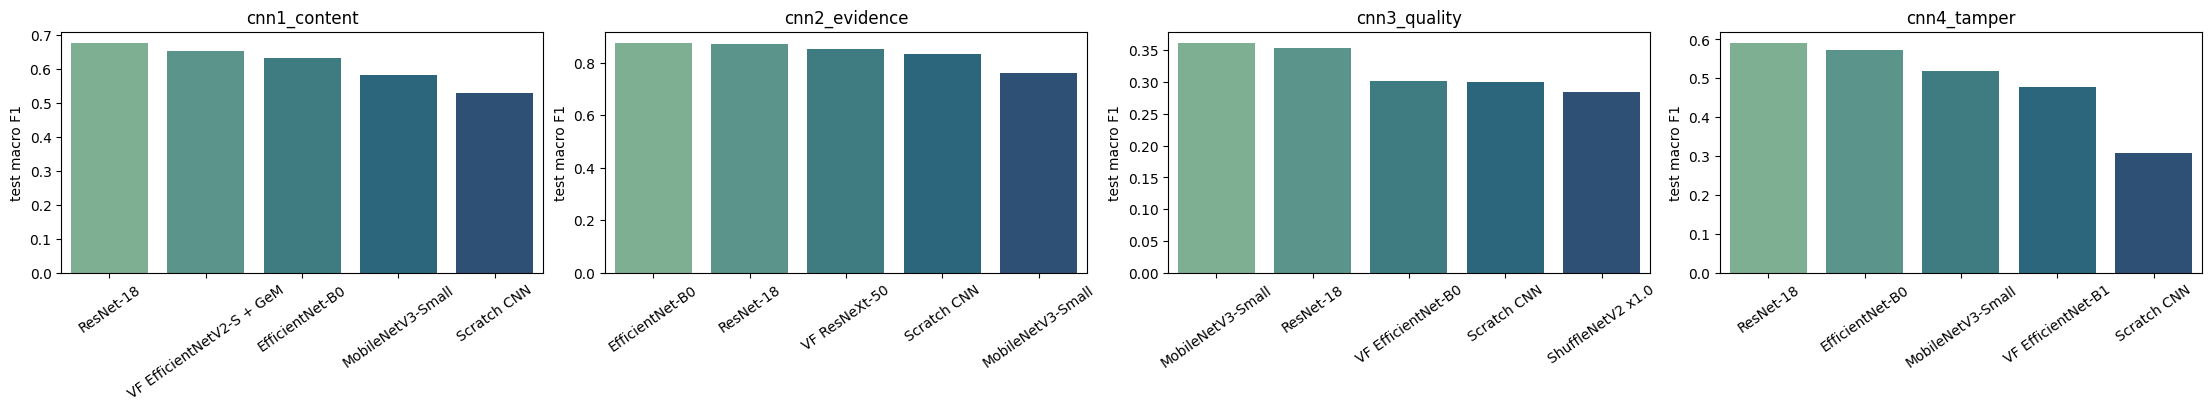

In [11]:
def measure_latency(model, loader):
    model = model.to(DEVICE)
    model.eval()
    x, _ = next(iter(loader))
    x = x[:1].to(DEVICE)
    with torch.no_grad():
        for _ in range(4):
            _ = model(x)
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        t0 = time.time()
        for _ in range(CFG["latency_reps"]):
            _ = model(x)
        if torch.cuda.is_available():
            torch.cuda.synchronize()
    latency = (time.time() - t0) * 1000 / CFG["latency_reps"]
    model.to("cpu")
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return latency

summary_rows = []
for run in RUNS:
    loaders = loaders_for(run["task"])
    latency = measure_latency(run["model"], loaders[2]) if loaders else None
    m = run["metrics"]
    summary_rows.append({"task": run["task"], "arch": run["arch"], "best_val_f1": run["best_val_f1"], "test_macro_f1": m["macro_f1"], "accuracy": m["accuracy"], "weighted_f1": m["weighted_f1"], "auc_macro_ovr": m["auc_macro_ovr"], "ece": m["ece"], "latency_ms": latency, "parameters": run["parameters"], "model_mb": run["model_mb"], "path": run["path"]})
comparison = pd.DataFrame(summary_rows).sort_values(["task", "test_macro_f1"], ascending=[True, False]).reset_index(drop=True)
display(comparison.style.format({"best_val_f1": "{:.3f}", "test_macro_f1": "{:.3f}", "accuracy": "{:.3f}", "weighted_f1": "{:.3f}", "auc_macro_ovr": "{:.3f}", "ece": "{:.3f}", "latency_ms": "{:.2f}", "model_mb": "{:.2f}"}))
comparison.to_csv(Path(CFG["output_dir"]) / "document_model_comparison_light.csv", index=False)
comparison.to_json(Path(CFG["output_dir"]) / "document_model_comparison_light.json", orient="records", indent=2)

fig, axes = plt.subplots(1, 4, figsize=(22, 4), constrained_layout=True)
for ax, task in zip(axes, TASKS):
    sub = comparison[comparison.task == task]
    sns.barplot(data=sub.assign(model=sub["arch"].map(ARCH_DISPLAY).fillna(sub["arch"])), x="model", y="test_macro_f1", ax=ax, palette="crest")
    ax.set_title(task)
    ax.set_xlabel("")
    ax.set_ylabel("test macro F1")
    ax.tick_params(axis="x", rotation=35)
plt.show()

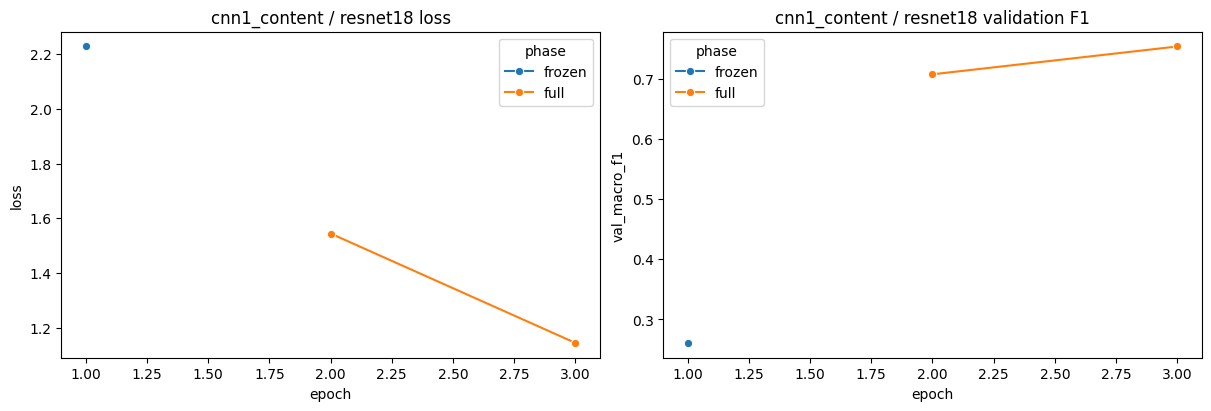

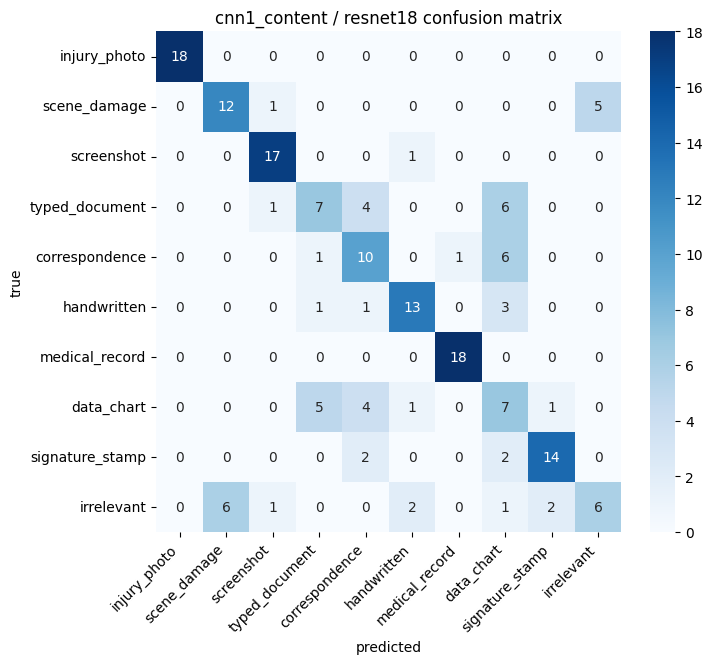

cnn1_content resnet18 {
  "accuracy": 0.6777777777777778,
  "macro_f1": 0.6766928636219671,
  "weighted_f1": 0.6766928636219672,
  "auc_macro_ovr": 0.9483196159122084,
  "ece": 0.1149136650065581,
  "per_class": {
    "injury_photo": {
      "precision": 1.0,
      "recall": 1.0,
      "f1": 1.0,
      "support": 18
    },
    "scene_damage": {
      "precision": 0.6666666666666666,
      "recall": 0.6666666666666666,
      "f1": 0.6666666666666666,
      "support": 18
    },
    "screenshot": {
      "precision": 0.85,
      "recall": 0.9444444444444444,
      "f1": 0.8947368421052632,
      "support": 18
    },
    "typed_document": {
      "precision": 0.5,
      "recall": 0.3888888888888889,
      "f1": 0.4375,
      "support": 18
    },
    "correspondence": {
      "precision": 0.47619047619047616,
      "recall": 0.5555555555555556,
      "f1": 0.5128205128205128,
      "support": 18
    },
    "handwritten": {
      "precision": 0.7647058823529411,
      "recall": 0.72222222222

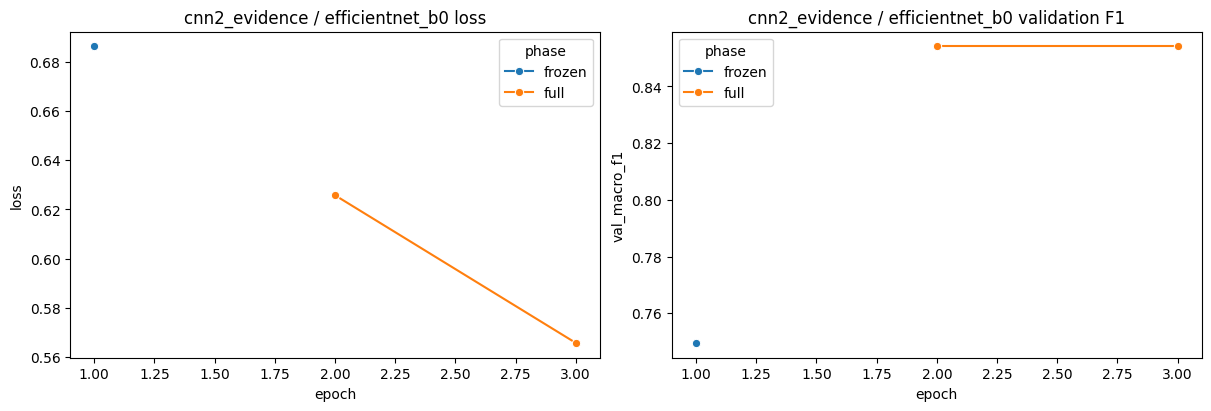

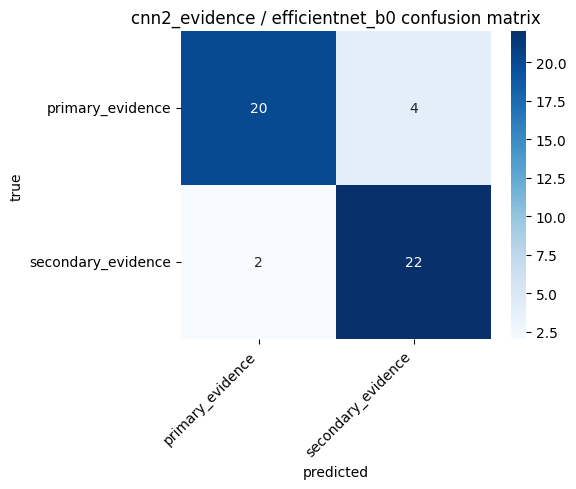

cnn2_evidence efficientnet_b0 {
  "accuracy": 0.875,
  "macro_f1": 0.8747826086956522,
  "weighted_f1": 0.8747826086956522,
  "auc_macro_ovr": 0.9340277777777779,
  "ece": 0.273017851014932,
  "per_class": {
    "primary_evidence": {
      "precision": 0.9090909090909091,
      "recall": 0.8333333333333334,
      "f1": 0.8695652173913043,
      "support": 24
    },
    "secondary_evidence": {
      "precision": 0.8461538461538461,
      "recall": 0.9166666666666666,
      "f1": 0.88,
      "support": 24
    }
  }
}


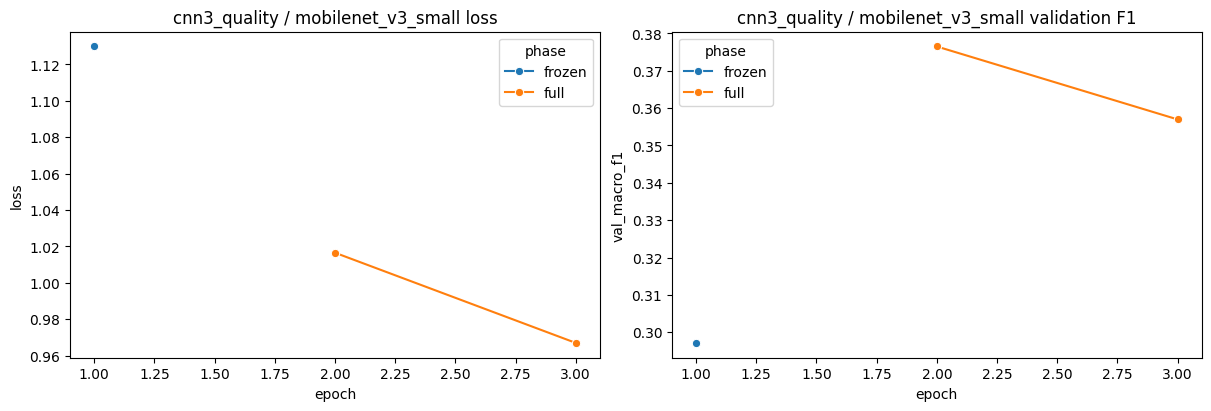

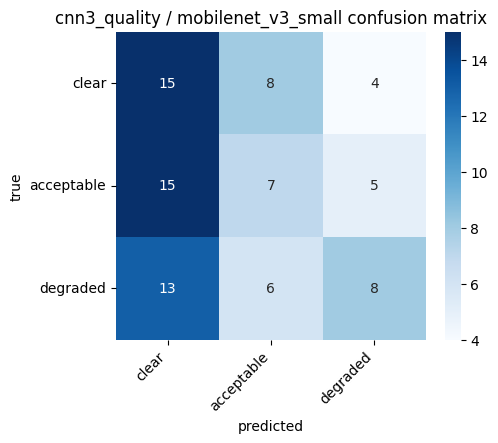

cnn3_quality mobilenet_v3_small {
  "accuracy": 0.37037037037037035,
  "macro_f1": 0.3612914862914863,
  "weighted_f1": 0.3612914862914863,
  "auc_macro_ovr": 0.5475537265660723,
  "ece": 0.09601162429209105,
  "per_class": {
    "clear": {
      "precision": 0.3488372093023256,
      "recall": 0.5555555555555556,
      "f1": 0.42857142857142855,
      "support": 27
    },
    "acceptable": {
      "precision": 0.3333333333333333,
      "recall": 0.25925925925925924,
      "f1": 0.2916666666666667,
      "support": 27
    },
    "degraded": {
      "precision": 0.47058823529411764,
      "recall": 0.2962962962962963,
      "f1": 0.36363636363636365,
      "support": 27
    }
  }
}


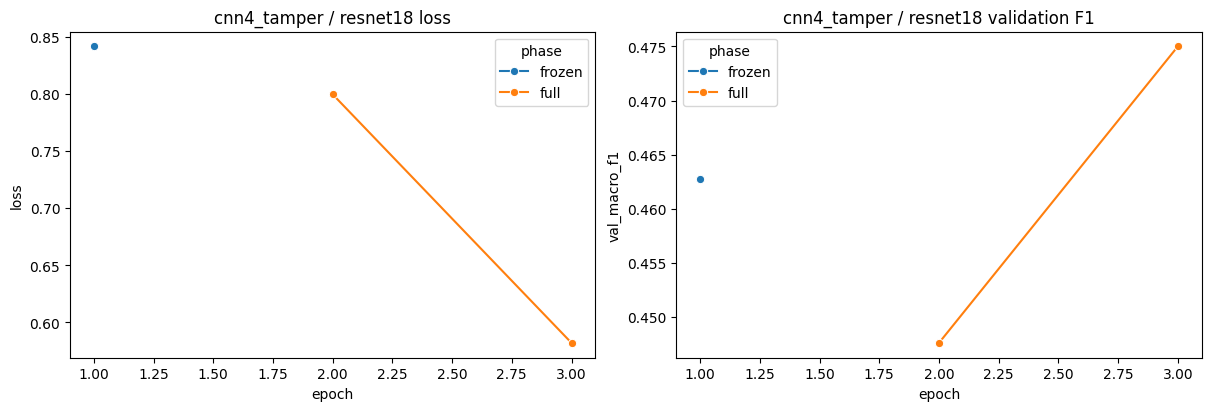

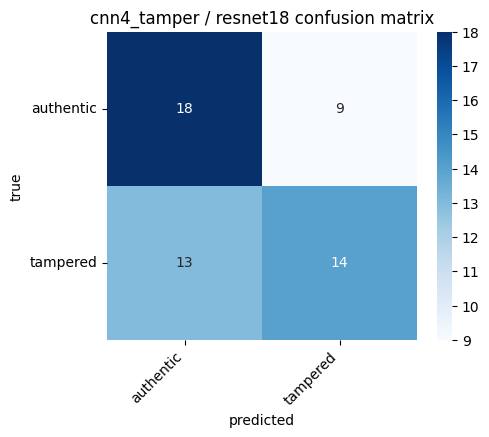

cnn4_tamper resnet18 {
  "accuracy": 0.5925925925925926,
  "macro_f1": 0.5903448275862069,
  "weighted_f1": 0.590344827586207,
  "auc_macro_ovr": 0.691358024691358,
  "ece": 0.17047397185254978,
  "per_class": {
    "authentic": {
      "precision": 0.5806451612903226,
      "recall": 0.6666666666666666,
      "f1": 0.6206896551724138,
      "support": 27
    },
    "tampered": {
      "precision": 0.6086956521739131,
      "recall": 0.5185185185185185,
      "f1": 0.56,
      "support": 27
    }
  }
}


In [12]:
def plot_history(run):
    df = pd.DataFrame(run["history"])
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
    sns.lineplot(data=df, x="epoch", y="loss", hue="phase", marker="o", ax=axes[0])
    sns.lineplot(data=df, x="epoch", y="val_macro_f1", hue="phase", marker="o", ax=axes[1])
    axes[0].set_title(f"{run['task']} / {run['arch']} loss")
    axes[1].set_title(f"{run['task']} / {run['arch']} validation F1")
    plt.show()

def plot_confusion(run):
    labels = TASKS[run["task"]]["labels"]
    cm = confusion_matrix(run["output"]["labels"], run["output"]["preds"], labels=list(range(len(labels))))
    fig, ax = plt.subplots(figsize=(max(5, len(labels) * 0.75), max(4, len(labels) * 0.65)))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_title(f"{run['task']} / {run['arch']} confusion matrix")
    ax.set_xlabel("predicted")
    ax.set_ylabel("true")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.show()

BEST_RUNS = {}
for task in TASKS:
    task_runs = [r for r in RUNS if r["task"] == task]
    if task_runs:
        BEST_RUNS[task] = max(task_runs, key=lambda r: r["metrics"]["macro_f1"])
        plot_history(BEST_RUNS[task])
        plot_confusion(BEST_RUNS[task])
        print(task, BEST_RUNS[task]["arch"], json.dumps(BEST_RUNS[task]["metrics"], indent=2)[:1600])

## Per-Class Metrics and Calibration

Per-class and calibration: cnn1_content / resnet18


,class,precision,recall,f1,support
0,injury_photo,1.000,1.000,1.000,18
1,scene_damage,0.667,0.667,0.667,18
2,screenshot,0.850,0.944,0.895,18
3,typed_document,0.500,0.389,0.438,18
4,correspondence,0.476,0.556,0.513,18
5,handwritten,0.765,0.722,0.743,18
6,medical_record,0.947,1.000,0.973,18
7,data_chart,0.280,0.389,0.326,18
8,signature_stamp,0.824,0.778,0.800,18
9,irrelevant,0.545,0.333,0.414,18


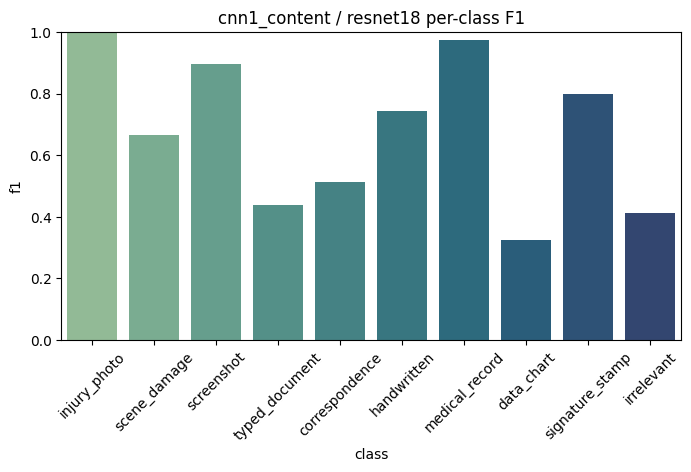

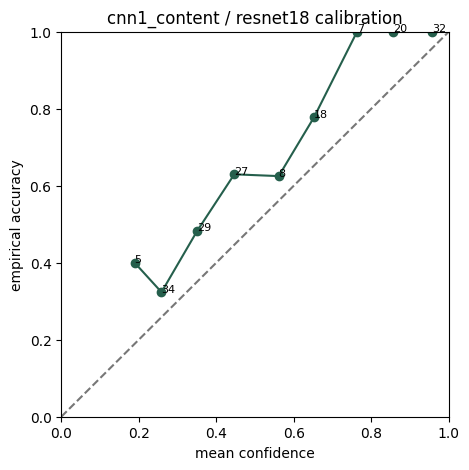

Per-class and calibration: cnn2_evidence / efficientnet_b0


,class,precision,recall,f1,support
0,primary_evidence,0.909,0.833,0.870,24
1,secondary_evidence,0.846,0.917,0.880,24


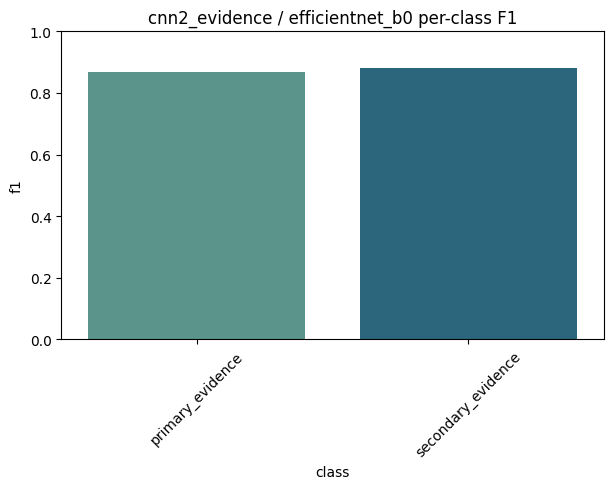

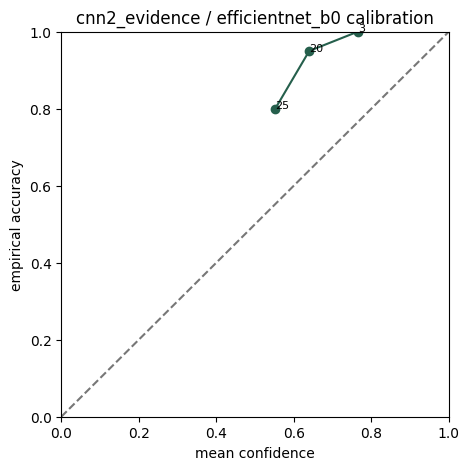

Per-class and calibration: cnn3_quality / mobilenet_v3_small


,class,precision,recall,f1,support
0,clear,0.349,0.556,0.429,27
1,acceptable,0.333,0.259,0.292,27
2,degraded,0.471,0.296,0.364,27


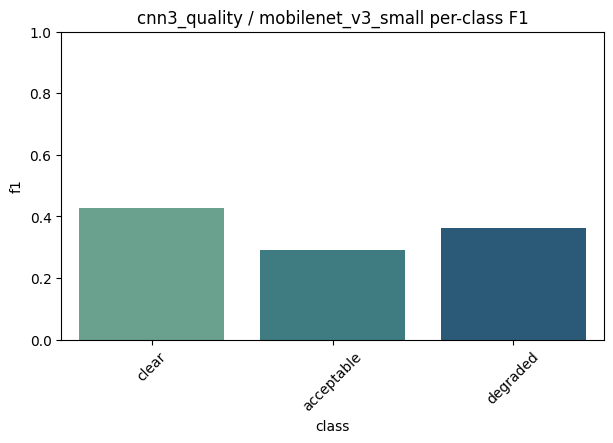

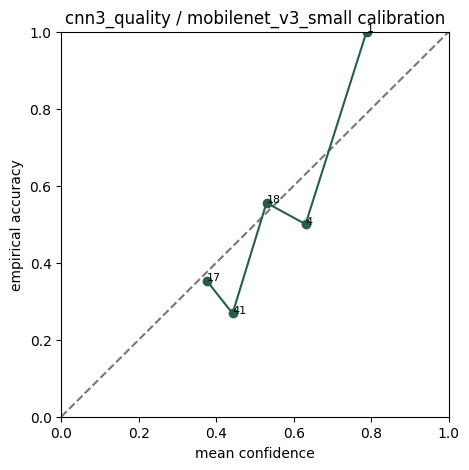

Per-class and calibration: cnn4_tamper / resnet18


,class,precision,recall,f1,support
0,authentic,0.581,0.667,0.621,27
1,tampered,0.609,0.519,0.560,27


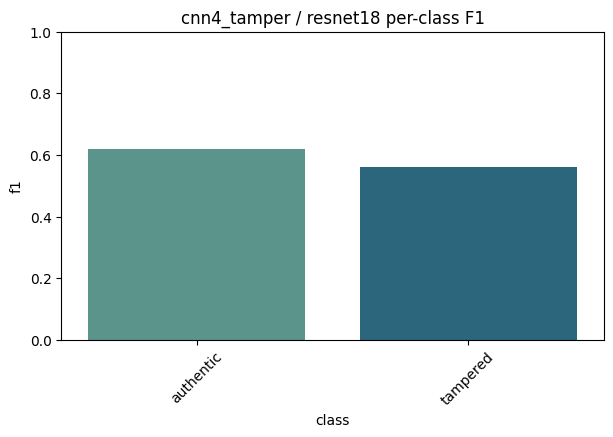

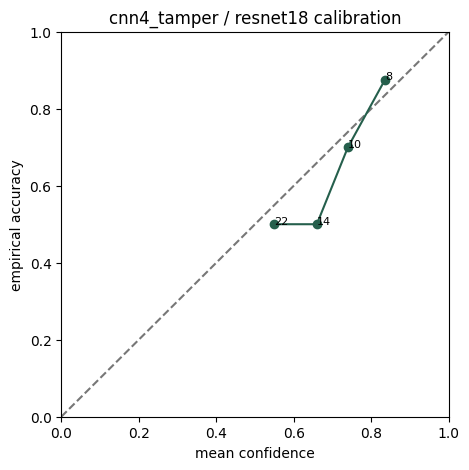

In [13]:
def plot_per_class_f1(run):
    rows = []
    for label, values in run["metrics"]["per_class"].items():
        rows.append({"class": label, "precision": values["precision"], "recall": values["recall"], "f1": values["f1"], "support": values["support"]})
    df = pd.DataFrame(rows)
    display(df.style.format({"precision": "{:.3f}", "recall": "{:.3f}", "f1": "{:.3f}"}))
    fig, ax = plt.subplots(figsize=(max(7, len(df) * 0.8), 4))
    sns.barplot(data=df, x="class", y="f1", ax=ax, palette="crest")
    ax.set_ylim(0, 1)
    ax.set_title(f"{run['task']} / {run['arch']} per-class F1")
    ax.tick_params(axis="x", rotation=45)
    plt.show()

def plot_calibration(run, bins=10):
    probs = run["output"]["probs"]
    labels = run["output"]["labels"]
    conf = probs.max(axis=1)
    ok = (probs.argmax(axis=1) == labels).astype(float)
    edges = np.linspace(0, 1, bins + 1)
    xs, ys, ns = [], [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (conf > lo) & (conf <= hi)
        if m.any():
            xs.append(float(conf[m].mean()))
            ys.append(float(ok[m].mean()))
            ns.append(int(m.sum()))
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.plot([0, 1], [0, 1], linestyle="--", color="#777")
    ax.plot(xs, ys, marker="o", color="#255f4c")
    for x, y, n in zip(xs, ys, ns):
        ax.text(x, y, str(n), fontsize=8)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("mean confidence")
    ax.set_ylabel("empirical accuracy")
    ax.set_title(f"{run['task']} / {run['arch']} calibration")
    plt.show()

for task, run in BEST_RUNS.items():
    print(f"Per-class and calibration: {task} / {run['arch']}")
    plot_per_class_f1(run)
    plot_calibration(run)

## Explainability

The notebook uses Grad-CAM on the selected best model for each task and perturbation occlusion as a model-agnostic check. Both are displayed inside the notebook and saved under the output folder.

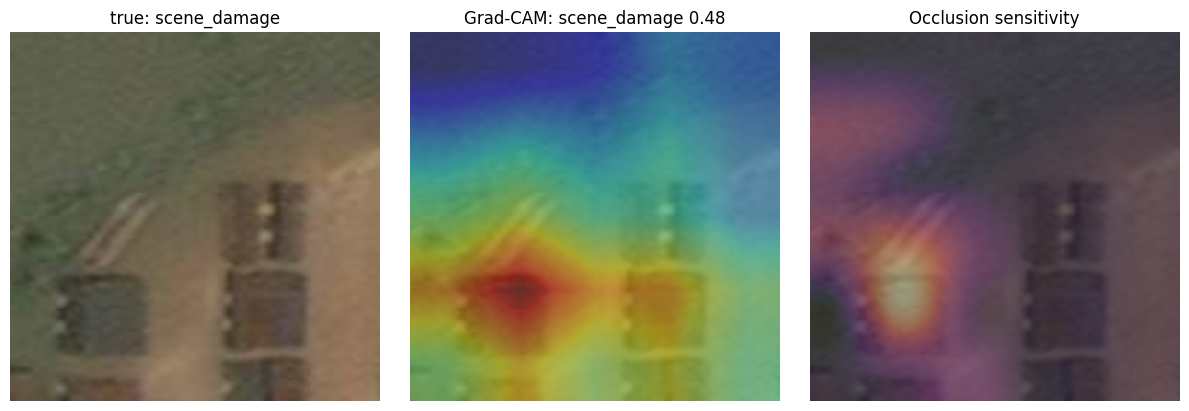

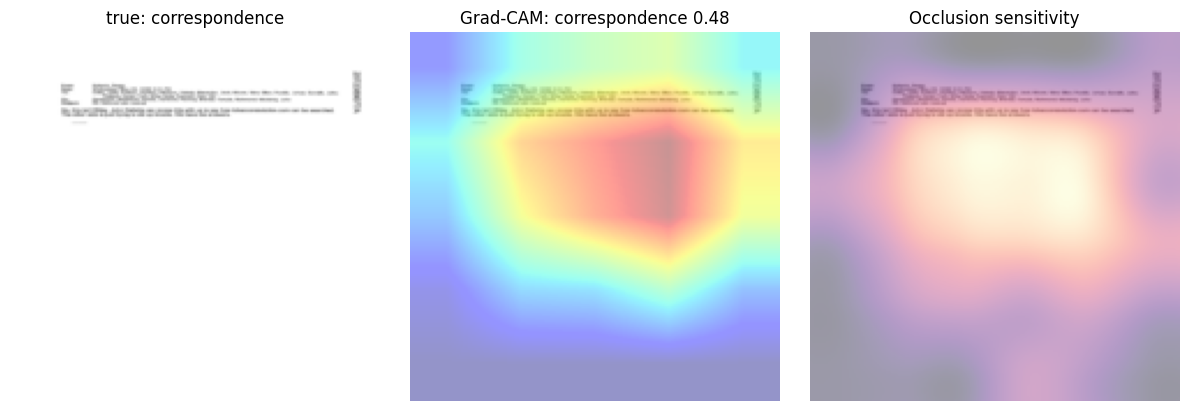

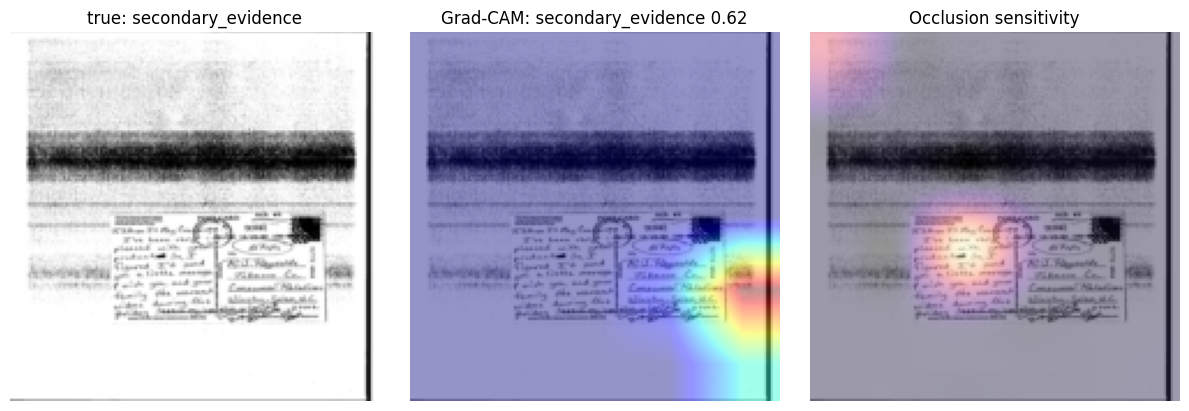

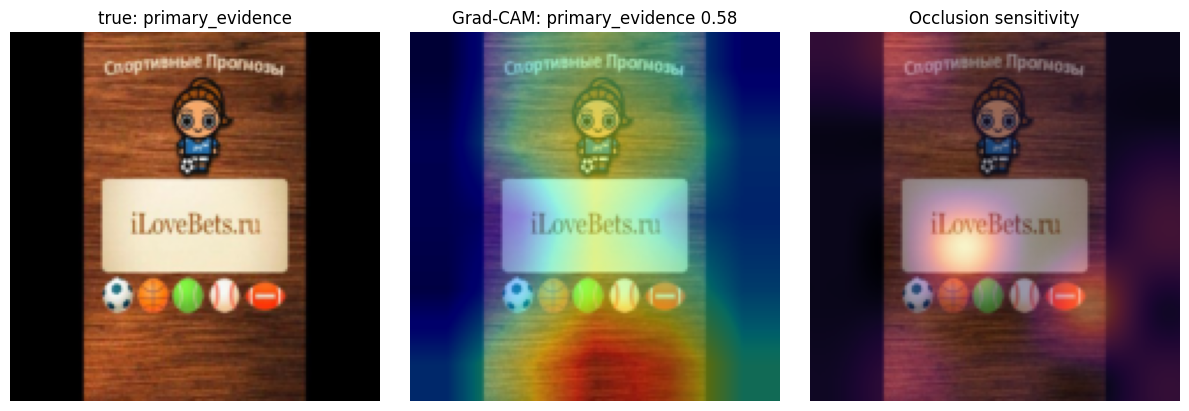

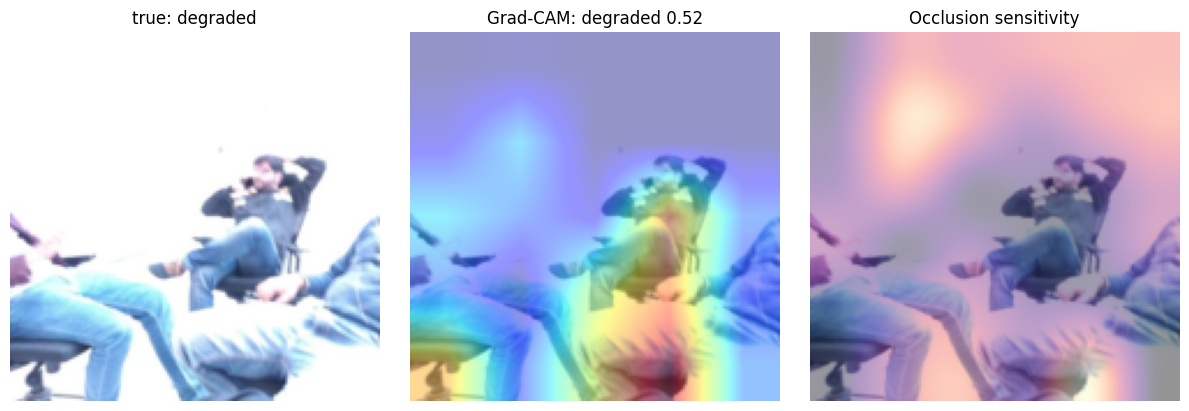

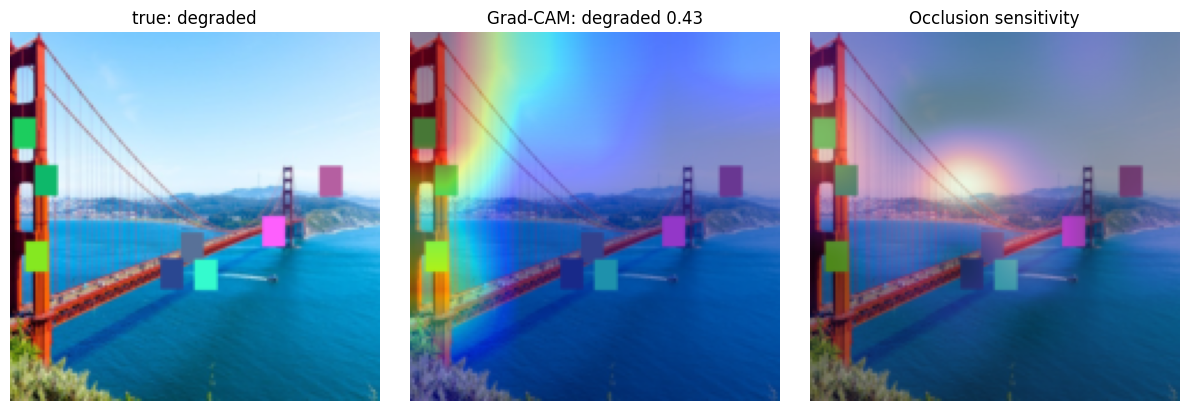

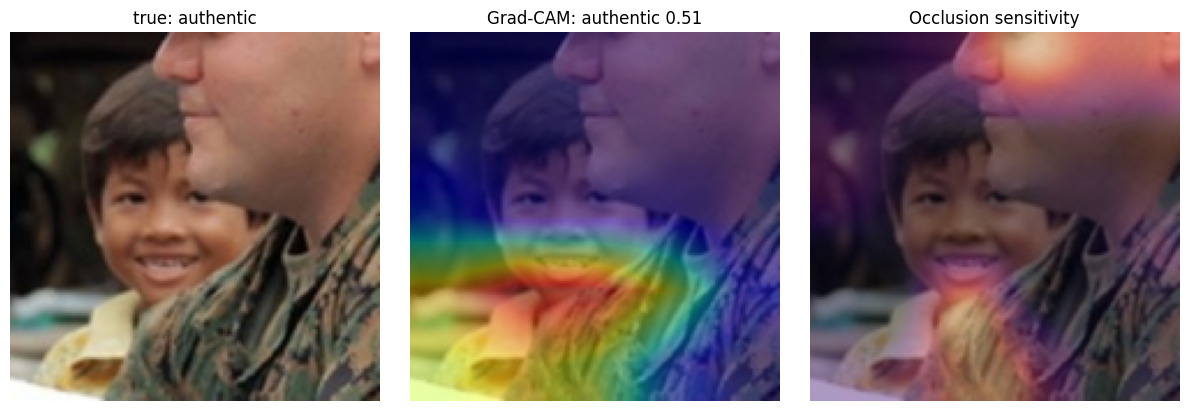

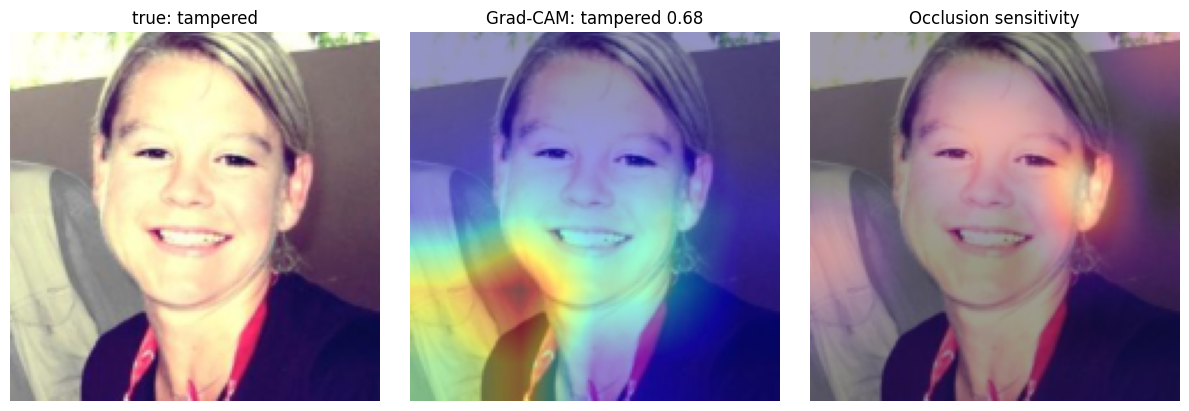

In [14]:
def denorm(x):
    mean = torch.tensor(MEAN).view(3, 1, 1)
    std = torch.tensor(STD).view(3, 1, 1)
    return (x.cpu() * std + mean).clamp(0, 1)

def last_conv_layer(model):
    last = None
    for m in model.modules():
        if isinstance(m, nn.Conv2d):
            last = m
    return last

def grad_cam(model, x, target_idx):
    model.eval()
    layer = last_conv_layer(model)
    if layer is None:
        return np.zeros((x.shape[-2], x.shape[-1]), dtype=np.float32)
    acts, grads = [], []
    def fwd_hook(module, inp, out):
        acts.append(out)
    def bwd_hook(module, gin, gout):
        grads.append(gout[0])
    h1 = layer.register_forward_hook(fwd_hook)
    h2 = layer.register_full_backward_hook(bwd_hook)
    model.zero_grad(set_to_none=True)
    out = model(x)
    out[:, target_idx].sum().backward()
    h1.remove()
    h2.remove()
    a = acts[0].detach()
    g = grads[0].detach()
    w = g.mean(dim=(2, 3), keepdim=True)
    cam = F.relu((w * a).sum(1, keepdim=True))
    cam = F.interpolate(cam, size=x.shape[-2:], mode="bilinear", align_corners=False)[0, 0]
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)
    return cam.cpu().numpy()

@torch.no_grad()
def occlusion_map(model, x, target_idx, grid=6):
    model.eval()
    base = F.softmax(model(x), dim=1)[0, target_idx].item()
    _, _, h, w = x.shape
    ph, pw = h // grid, w // grid
    heat = np.zeros((grid, grid), dtype=np.float32)
    for i in range(grid):
        for j in range(grid):
            xx = x.clone()
            xx[:, :, i*ph:(i+1)*ph, j*pw:(j+1)*pw] = 0
            score = F.softmax(model(xx), dim=1)[0, target_idx].item()
            heat[i, j] = max(0.0, base - score)
    if heat.max() > 0:
        heat /= heat.max()
    return cv2.resize(heat, (w, h), interpolation=cv2.INTER_CUBIC)

def xai_examples(run):
    task = run["task"]
    run["model"] = run["model"].to(DEVICE)
    _, _, test_df, c2i = SPLITS[task]
    inv = {v: k for k, v in c2i.items()}
    out = run["output"]
    correct = np.where(out["labels"] == out["preds"])[0]
    if len(correct) == 0:
        correct = np.arange(min(len(test_df), CFG["xai_examples_per_task"]))
    chosen = correct[:CFG["xai_examples_per_task"]]
    out_dir = Path(CFG["output_dir"]) / "xai" / task
    out_dir.mkdir(parents=True, exist_ok=True)
    files = []
    for n, idx in enumerate(chosen):
        row = test_df.iloc[int(idx)]
        try:
            img = Image.open(row.path).convert("RGB")
        except Exception:
            img = Image.new("RGB", (CFG["img_size"], CFG["img_size"]), "white")
        x = eval_tf(img).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            probs = F.softmax(run["model"](x), dim=1)[0].detach().cpu().numpy()
        pred = int(probs.argmax())
        cam = grad_cam(run["model"], x, pred)
        occ = occlusion_map(run["model"], x, pred)
        shown = np.transpose(denorm(x[0]).numpy(), (1, 2, 0))
        fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)
        axes[0].imshow(shown)
        axes[0].set_title(f"true: {row.label}")
        axes[1].imshow(shown)
        axes[1].imshow(cam, cmap="jet", alpha=0.42)
        axes[1].set_title(f"Grad-CAM: {inv[pred]} {probs[pred]:.2f}")
        axes[2].imshow(shown)
        axes[2].imshow(occ, cmap="magma", alpha=0.42)
        axes[2].set_title("Occlusion sensitivity")
        for ax in axes:
            ax.axis("off")
        fp = out_dir / f"{run['arch']}_{n}.png"
        fig.savefig(fp, dpi=140, bbox_inches="tight")
        files.append(str(fp))
        plt.show()
    run["model"].to("cpu")
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return files

XAI_FILES = []
for task, run in BEST_RUNS.items():
    XAI_FILES.extend(xai_examples(run))

## Final Selection and Output Files

In [ ]:
best_table = []
for task, run in BEST_RUNS.items():
    m = run["metrics"]
    best_table.append({"task": task, "best_arch": run["arch"], "best_model_display": ARCH_DISPLAY.get(run["arch"], run["arch"]), "final_vf_arch": TASKS[task]["final_arch"], "final_vf_display": ARCH_DISPLAY.get(TASKS[task]["final_arch"], TASKS[task]["final_arch"]), "selected_final_vf": run["arch"] == TASKS[task]["final_arch"], "test_macro_f1": m["macro_f1"], "accuracy": m["accuracy"], "auc_macro_ovr": m["auc_macro_ovr"], "ece": m["ece"], "path": run["path"]})
best_df = pd.DataFrame(best_table)
display(best_df.style.format({"test_macro_f1": "{:.3f}", "accuracy": "{:.3f}", "auc_macro_ovr": "{:.3f}", "ece": "{:.3f}"}))
summary = {"purpose": "document model comparison", "tasks": TASKS, "dataset_audit": DATA_AUDIT, "comparison": comparison.to_dict("records"), "best_by_task": best_table, "xai_files": XAI_FILES}
summary_path = Path(CFG["output_dir"]) / "comparison_summary.json"
summary_path.write_text(json.dumps(summary, indent=2), encoding="utf-8")
print(f"Saved summary: {summary_path}")
display(Markdown(f"Saved comparison CSV: `{Path(CFG["output_dir"]) / "document_model_comparison_light.csv"}`"))
display(Markdown(f"Saved comparison JSON: `{Path(CFG["output_dir"]) / "document_model_comparison_light.json"}`"))
display(Markdown(f"Saved summary JSON: `{summary_path}`"))

,task,best_arch,best_model_display,final_vf_arch,final_vf_display,selected_final_vf,test_macro_f1,accuracy,auc_macro_ovr,ece,path
0,cnn1_content,resnet18,ResNet-18,final_effnetv2s_gem,VF EfficientNetV2-S + GeM,False,0.677,0.678,0.948,0.115,/kaggle/working/document_model_comparison_light/cnn1_content_resnet18.pt
1,cnn2_evidence,efficientnet_b0,EfficientNet-B0,final_resnext50,VF ResNeXt-50,False,0.875,0.875,0.934,0.273,/kaggle/working/document_model_comparison_light/cnn2_evidence_efficientnet_b0.pt
2,cnn3_quality,mobilenet_v3_small,MobileNetV3-Small,final_effnetb0,VF EfficientNet-B0,False,0.361,0.370,0.548,0.096,/kaggle/working/document_model_comparison_light/cnn3_quality_mobilenet_v3_small.pt
3,cnn4_tamper,resnet18,ResNet-18,final_effnetb1,VF EfficientNet-B1,False,0.590,0.593,0.691,0.170,/kaggle/working/document_model_comparison_light/cnn4_tamper_resnet18.pt


Saved summary: /kaggle/working/document_model_comparison_light/comparison_summary.json


Saved comparison CSV: `/kaggle/working/document_model_comparison_light/document_model_comparison_light.csv`

Saved comparison JSON: `/kaggle/working/document_model_comparison_light/document_model_comparison_light.json`

Saved summary JSON: `/kaggle/working/document_model_comparison_light/comparison_summary.json`